In [156]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme(style="whitegrid")
from pathlib import Path
import joblib

from sklearn.model_selection import(
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
    cross_val_predict,
)


from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from pandas.plotting import scatter_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
RANDOM_SEED = 42

In [96]:
df = pd.read_csv("housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


## Saknade värden

In [98]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

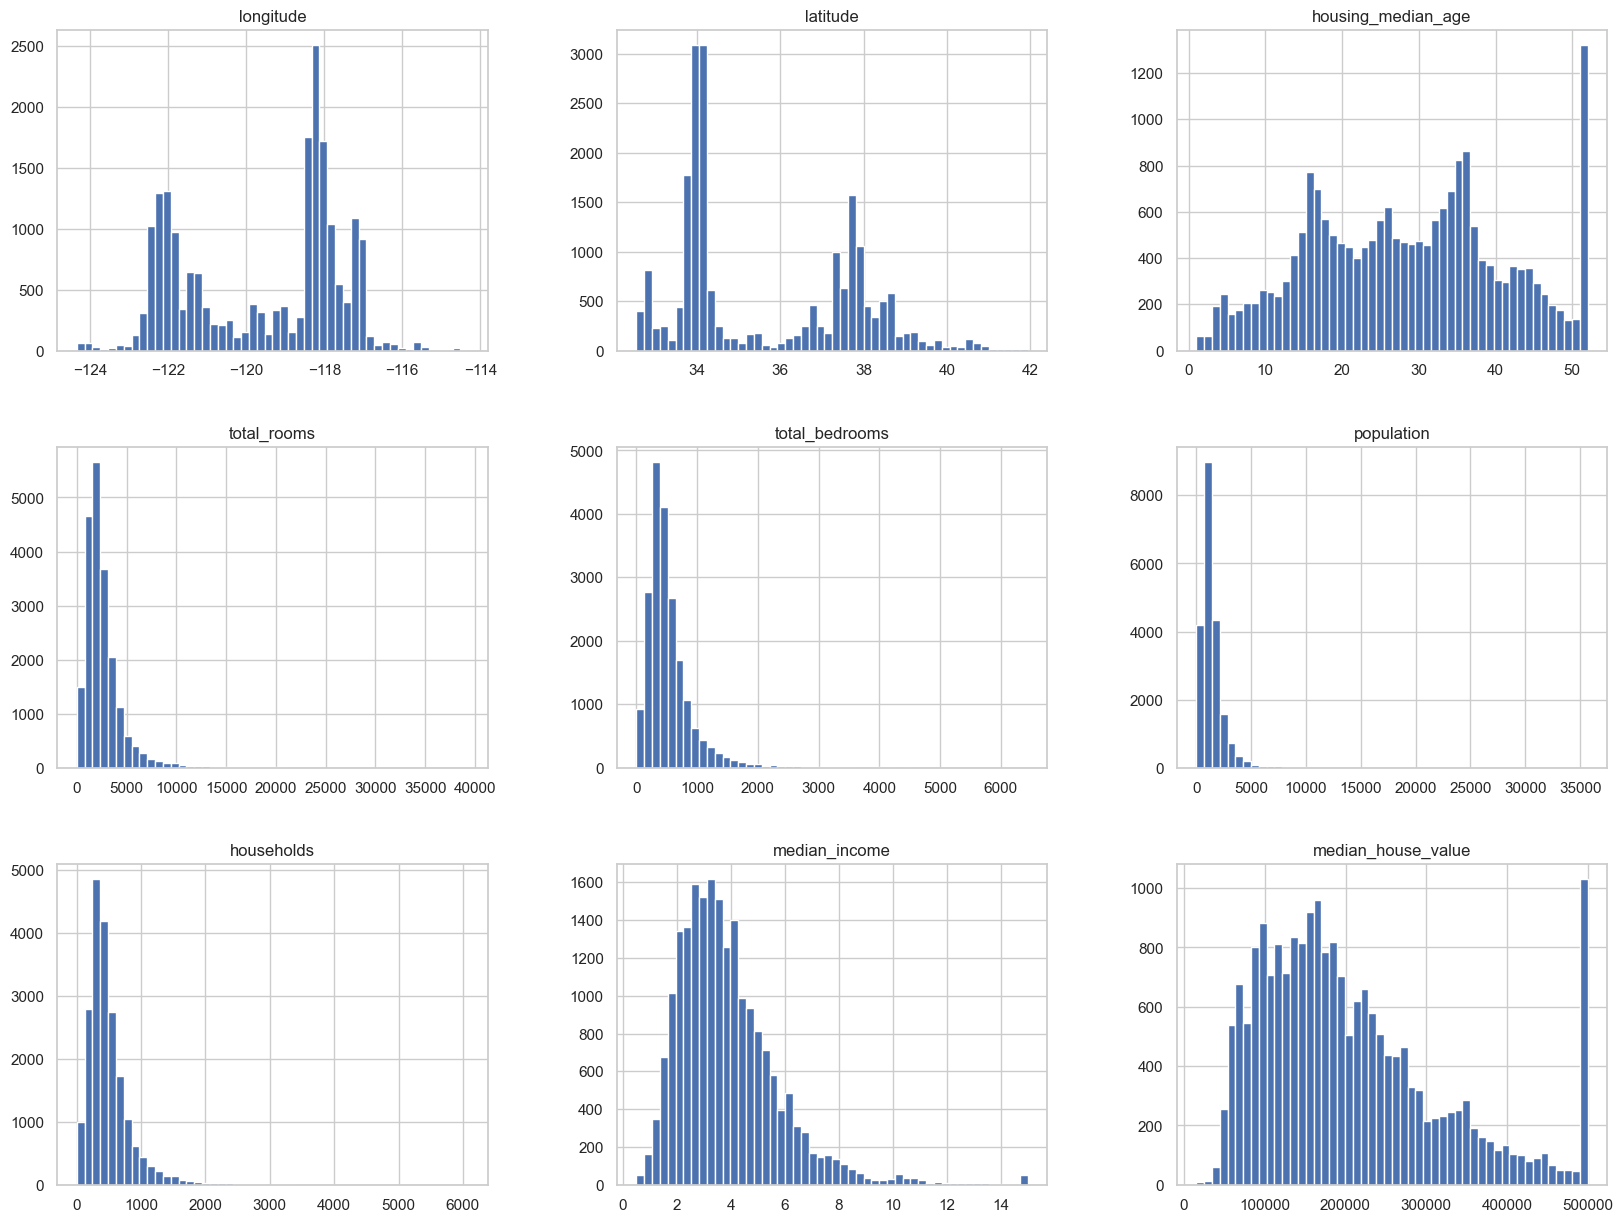

In [99]:
df.hist(bins=50, figsize=(20,15))
plt.show()


I boken tog dom upp att olika features har ett tak och tittar vi på median house value ser vi tydligt var gränsen går. 

In [100]:
df["median_house_value"].value_counts().sort_index(ascending=False).head()

median_house_value
500001.0    965
500000.0     27
499100.0      1
499000.0      1
498800.0      1
Name: count, dtype: int64

Housing_median_age har också ett tak på 52år viket vi tydligt ser i resultatet nedan

In [101]:
df["housing_median_age"].value_counts().sort_index(ascending=False).head()

housing_median_age
52.0    1273
51.0      48
50.0     136
49.0     134
48.0     177
Name: count, dtype: int64

Sist men inte minst så har median income också ett tak på både en nedre gräns på 0.49.. och en övre gräns på 49.

In [102]:
print("Nedre gräns",df["median_income"].value_counts().sort_index(ascending=True).head())
print("Övre gräns",df["median_income"].value_counts().sort_index(ascending=False).head())

Nedre gräns median_income
0.4999    12
0.5360    10
0.5495     1
0.6433     1
0.6775     1
Name: count, dtype: int64
Övre gräns median_income
15.0001    49
15.0000     2
14.9009     1
14.5833     1
14.4219     1
Name: count, dtype: int64


In [103]:
mask = (
    (df["median_house_value"] < 500000) &
    (df["housing_median_age"] < 52) &
    (df["median_income"] >= 0.5) &
    (df["median_income"] <= 15)
)

df = df[mask]



In [104]:

corr_matrix = df.select_dtypes(include=["number"]).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.664747
total_rooms           0.153854
households            0.100471
total_bedrooms        0.079807
population            0.022386
housing_median_age    0.014217
longitude            -0.022921
latitude             -0.171532
Name: median_house_value, dtype: float64

Här gör vi en snabb analys av korrelationen mellan de olika features och target-värdet. Vi ser tydligt att medianinkomsten har högst korrelation, och därför använder vi den som stratifieringsvariabel när vi delar upp datan i tränings- och testdata.

Jag trodde tidigare att stratifiering bara användes vid klassificering, men boken förklarar att man även kan stratifiera en variabel som korrelerar starkt med target-värdet i regressionsproblem.

Vi delar därför in medianinkomsten i fem intervall (grupper). Fördelningen av dessa grupper ska sedan vara ungefär lika i både träningsdatan och testdatan. Detta gör att testdatan blir mer representativ för hela datasetet.

In [105]:
df["income_cat"] = np.ceil(df["median_income"] / 1.5)
df.loc[df["income_cat"] >= 5, "income_cat"] = 5.0
stratifyed_label = df["income_cat"]

## Nya colummer

In [106]:
df["rooms_per_household"] = df["total_rooms"]/df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"]/df["total_rooms"]
df["population_per_household"]=df["population"]/df["households"]

## Se om the nya colomerna har hög korelation

In [107]:
df = df.drop("income_cat", axis=1)
corr_matrix = df.select_dtypes(include=["number"]).corr()
print(corr_matrix["median_house_value"].sort_values(ascending=False))

df["income_cat"] = stratifyed_label

median_house_value          1.000000
median_income               0.664747
total_rooms                 0.153854
rooms_per_household         0.115245
households                  0.100471
total_bedrooms              0.079807
population                  0.022386
housing_median_age          0.014217
population_per_household   -0.020236
longitude                  -0.022921
latitude                   -0.171532
bedrooms_per_room          -0.232205
Name: median_house_value, dtype: float64


In [108]:



num_cols = [
    'longitude', 'latitude', 'housing_median_age', 'total_rooms',
    'total_bedrooms', 'population', 'households', 'median_income',
    'median_house_value', "rooms_per_household" ,"bedrooms_per_room",
    "population_per_household"
    
    ]

cat_cols = ['ocean_proximity']


drop_columns = [
    'median_house_value'
    ]


X = df.drop(columns= drop_columns)
y = df['median_house_value']


columns_used = [c for c in X.columns if c not in drop_columns]


## Delar datan i train och test

In [109]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state= RANDOM_SEED,
    stratify=stratifyed_label
)

print(X_train["income_cat"].value_counts() / len(X_train))
print(X_test["income_cat"].value_counts() / len(X_test))

X_test.drop("income_cat", axis=1, inplace=True)
X_train.drop("income_cat", axis=1, inplace=True)



income_cat
3.0    0.358722
2.0    0.332098
4.0    0.181720
5.0    0.088231
1.0    0.039229
Name: count, dtype: float64
income_cat
3.0    0.358760
2.0    0.332075
4.0    0.181671
5.0    0.088410
1.0    0.039084
Name: count, dtype: float64


In [110]:
housing = X.copy()
housing["median_house_value"] = y_train

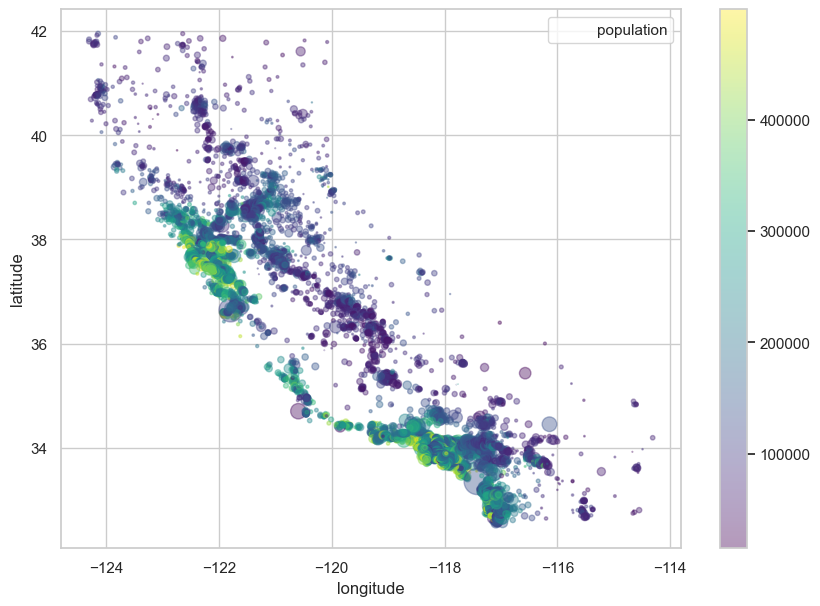

In [111]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c=housing["median_house_value"], cmap="viridis", colorbar=True)

plt.legend()



Grafen visar tydligt att avståndet till havet samt mängden invånare i området stor betydelse för median priset för ett hus.

## PipeLine

In [112]:

selected_num_cols = [x for x in columns_used if x in num_cols]
selected_cat_cols = [x for x in columns_used if x in cat_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])



preprocess = ColumnTransformer([
    ("num", num_pipe, selected_num_cols),
    ("cat", cat_pipe, selected_cat_cols)
])

def make_model(model):
    return Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

In [113]:
lg = LinearRegression()

rf = RandomForestRegressor(
    random_state=RANDOM_SEED,
    n_jobs=-1
)

dt = DecisionTreeRegressor(
    random_state=RANDOM_SEED
)

gb = GradientBoostingRegressor(
    random_state=RANDOM_SEED
)

ridge = Ridge(random_state=RANDOM_SEED)

lasso = Lasso(random_state=RANDOM_SEED)

xgb = XGBRegressor(random_state=RANDOM_SEED)

model_dummy = DummyRegressor(strategy="mean")

In [114]:
model_lr = make_model(lg)
model_rf = make_model(rf)
model_dt = make_model(dt)
model_gb = make_model(gb)
model_ridge = make_model(ridge)
model_lasso = make_model(lasso)
model_xgb = make_model(xgb)
model_dummy = make_model(model_dummy)

## Vilken modell presterar bäst på CV?

In [115]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "neg_root_mean_squared_error"

Anledingen till varför vi kör på RMSE är pga den straffar större fel. Detta leder till att den blir känslig för outliers. Vi vill ha en modell som unviker stora misstag.

In [116]:
models = {
    "Dummy": model_dummy,
    "LinearRegression": model_lr,
    "RandomForest": model_rf,
    "DecisionTree": model_dt,
    "GradientBoosting": model_gb,
    "XGBoost": model_xgb,
    "Ridge": model_ridge,
    "Lasso": model_lasso
}


baseline_rows = []

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING)
    baseline_rows.append({"model": name, "mean": scores.mean(), "std": scores.std()})

baseline_table = pd.DataFrame(baseline_rows).sort_values("mean", ascending=False)
baseline_table

,model,mean,std
5,XGBoost,-41732.445912,1342.980125
2,RandomForest,-44481.988716,1358.820117
4,GradientBoosting,-47103.140537,1135.143412
6,Ridge,-57759.219111,925.452374
7,Lasso,-57759.591298,925.941539
1,LinearRegression,-57759.809391,926.341389
3,DecisionTree,-63243.847179,2456.482459
0,Dummy,-95505.588878,1295.536501


## Top 2 modeller

In [117]:
top2_models = baseline_table["model"].head(2).tolist()
print("top-2 models", top2_models)

best_model = models[top2_models[0]]
second_best_model = models[top2_models[1]]

top-2 models ['XGBoost', 'RandomForest']


## Hyperparametrar för alla modeller

Testade med olika hyperparametrar och dessa blev bäst, tog bort alla dom andra så ni slipper vänta på träningen.

In [135]:
param_rf ={'model__max_depth': [15],
 'model__min_samples_leaf': [4],
 'model__min_samples_split': [2],
 'model__n_estimators': [300]}


param_xgb = {'model__learning_rate': [0.05],
 'model__max_depth': [7],
 'model__n_estimators': [500],
 'model__subsample': [0.8]}

In [136]:
grid_xgb = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_xgb,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    verbose=2
    )

grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05], 'model__max_depth': [7], 'model__n_estimators': [500], 'model__subsample': [0.8]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : t

In [120]:
grid_xgb.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 7,
 'model__n_estimators': 500,
 'model__subsample': 0.8}

In [137]:
grid_rf = GridSearchCV(
    estimator=model_rf,
    param_grid=param_rf,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    verbose=2
    )

grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [15], 'model__min_samples_leaf': [4], 'model__min_samples_split': [2], 'model__n_estimators': [300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >

In [122]:
grid_rf.best_params_


{'model__max_depth': 15,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 2,
 'model__n_estimators': 300}

## Bästa modellen



In [138]:
print(grid_xgb.best_score_)
print(grid_rf.best_score_)

if grid_xgb.best_score_ > grid_rf.best_score_:
    print("The winner is Xgboost")
else:
    print("´The winner is: Random Forest")

best_model = grid_xgb if grid_xgb.best_score_ > grid_rf.best_score_ else grid_rf

-39901.25858363164
-44536.91888741219
The winner is Xgboost


## Feature imporance

## Tree importance

In [124]:

model_step = best_model.best_estimator_.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    feature_names = best_model.best_estimator_.named_steps["preprocess"].get_feature_names_out()

    importances = model_step.feature_importances_

    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

    print(fi)

else:
    print("This model does not support feature_importances_.")


cat__ocean_proximity_INLAND        0.664449
num__median_income                 0.142953
num__population_per_household      0.036085
cat__ocean_proximity_NEAR OCEAN    0.026738
num__latitude                      0.021338
num__longitude                     0.017230
num__housing_median_age            0.014429
cat__ocean_proximity_NEAR BAY      0.013540
cat__ocean_proximity_<1H OCEAN     0.011741
num__rooms_per_household           0.010472
num__bedrooms_per_room             0.009657
num__total_bedrooms                0.008977
num__households                    0.008130
num__population                    0.007438
num__total_rooms                   0.006826
dtype: float32


Tree Feature Importance handlar om hur mycket en feature minskar felet när beslutsträdet gör en split på den variabeln. Om trädet ofta delar upp datan baserat på till exempel median_income, kommer den featuren att få hög betydelse.

Problemet är att tree importance är biased mot one-hot-encodade variabler, vilket kan skapa problem. Till exempel kan vi se att INLAND som skapades från One Hot får väldigt hög betydelse i prediktionen.

Därför använder vi istället något som kallas Permutation Importance, som mäter hur mycket modellen faktiskt är beroende av en feature genom att slumpmässigt blanda (permutera) värdena för en feature och se hur mycket modellens prestanda försämras.

## Permutation importance

In [125]:

result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)

importances = pd.Series(result.importances_mean, index=X_test.columns)
importances.sort_values(ascending=False)

latitude                    58964.336543
longitude                   57467.362493
median_income               28848.690967
ocean_proximity             13180.544738
population_per_household    11939.015468
housing_median_age           5369.644846
bedrooms_per_room            3999.208203
rooms_per_household          3733.421263
population                    638.976834
total_rooms                   580.494115
total_bedrooms                387.146920
households                    315.045113
dtype: float64

Här säger den att platsen spelar stor roll med hjälp av latitud och longitud

## Test datan

RMSE: 40065.768419586784
MAE: 26268.9631938595


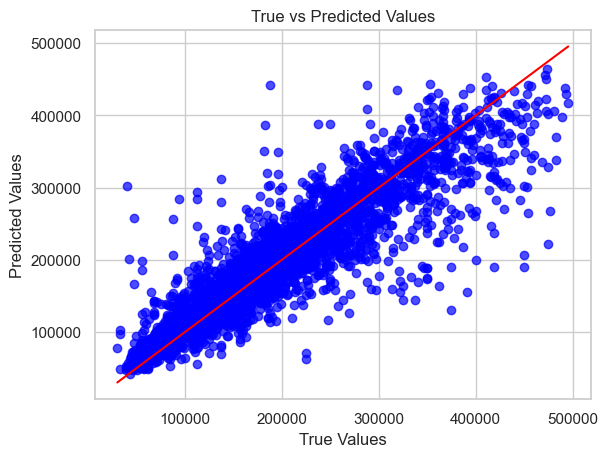

In [157]:
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.show()

Vi ser tydligt att vår modell presterar bra och att våra prediktioner korrelerar med de sanna värdena. Vi kan också se att felen tenderar att bli större för högre värden. Vi får även en MAE på bara ca 26000 vilket är väldigt bra.

## PCA
Visualisera datan för att se om det finns några clusters

In [ ]:
X_scaled = preprocess.fit_transform(X)
columns = preprocess.get_feature_names_out()

array(['num__longitude', 'num__latitude', 'num__housing_median_age',
       'num__total_rooms', 'num__total_bedrooms', 'num__population',
       'num__households', 'num__median_income',
       'num__rooms_per_household', 'num__bedrooms_per_room',
       'num__population_per_household', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN'],
      dtype=object)

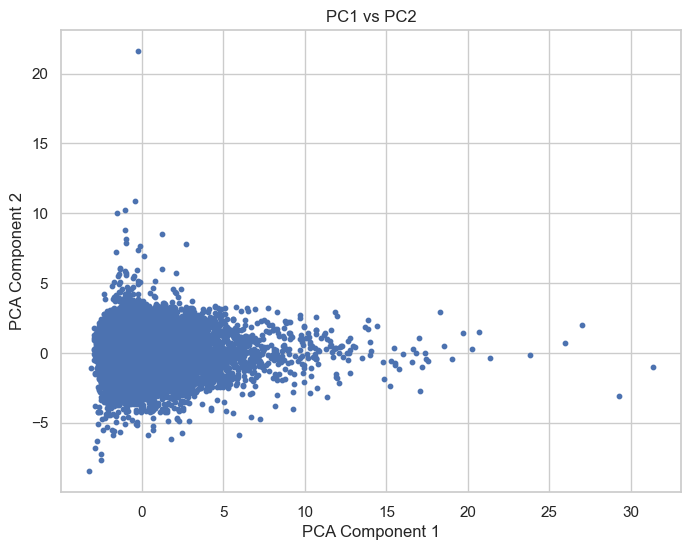

In [127]:
# PCA med 2 komponenter
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PC1 vs PC2")
plt.show()

## KMeans

,K,inertia,silhouette
0,2,176673.917379,0.366047
1,3,146163.784578,0.249392
2,4,132283.522591,0.212078
3,5,116657.684871,0.212080
4,6,106084.488325,0.217048
5,7,99081.813847,0.193975
6,8,93699.060102,0.175855
7,9,85472.129656,0.176683
8,10,81410.125782,0.177601


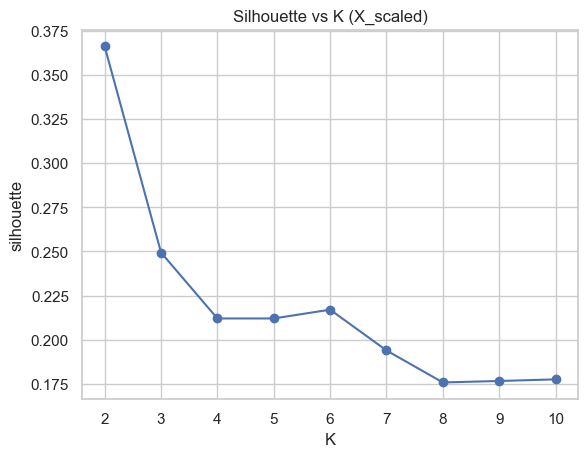

In [128]:

results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append({"K": k, "inertia": kmeans.inertia_, "silhouette": score})

results_df =pd.DataFrame(results)
display(results_df)

plt.figure()
plt.plot(results_df["K"], results_df["silhouette"], marker="o")
plt.xlabel("K")
plt.ylabel("silhouette")
plt.title("Silhouette vs K (X_scaled)")
plt.grid(True)
plt.show()


In [129]:
K_final = 2
kmeans_final = KMeans(n_clusters=K_final, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

print(pd.Series(cluster_labels).value_counts().sort_index())

0    16374
1     2172
Name: count, dtype: int64


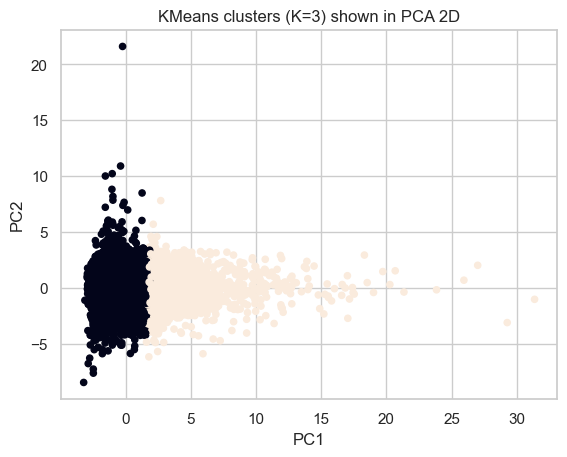

In [130]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters (K=3) shown in PCA 2D")
plt.grid(True)
plt.show()

In [141]:
profile_scaled= pd.DataFrame(X_scaled, columns=preprocess.get_feature_names_out())
profile_scaled["cluster"] = cluster_labels
profile_scaled = profile_scaled.groupby("cluster").mean()

display(profile_scaled.iloc[:, :])

,num__longitude,num__latitude,num__housing_median_age,num__total_rooms,num__total_bedrooms,num__population,num__households,num__median_income,num__rooms_per_household,num__bedrooms_per_room,num__population_per_household,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN
cluster,,,,,,,,,,,,,,,,
0,-0.018639,0.017935,0.116862,-0.256486,-0.265947,-0.245614,-0.266055,-0.029961,-0.008208,0.000017,0.002879,0.446623,0.340540,0.000122,0.085074,0.127641
1,0.140516,-0.135203,-0.880985,1.933564,2.004884,1.851602,2.005705,0.225869,0.061877,-0.000127,-0.021707,0.463168,0.350829,0.000000,0.079190,0.106814
